# 2×2 VLM evaluation harness — LFM2.5-VL-450M vs SmolVLM2-500M × prompt v1 vs v2+grammar

**Setup (once):** unzip the `vlm_eval` project folder into Google Drive so it sits at the `PROJECT_DIR` below
(default `MyDrive/vlm_eval`). Put your source frames in `data/raw_frames/` (or a video in `data/`) and, if you have it,
`labeled_frames.html` in `data/`.

**Then run top to bottom.** Every step writes to Drive, so if Colab disconnects you just re-run from the top: finished
steps are skipped (frames already letterboxed, boxes already confirmed, experiment frames already answered).

Two entry points:
* **First time:** Step 0 (intake + tagging) → Step 5 (servers) → Step 7 (run) → Step 8/9 (metrics, analysis).
* **Re-run with an existing `data/manifest.json`:** set `INTAKE_MODE = "skip"` and start from Step 0e.

All the logic is in `src/harness.py`; this notebook is just config + calls, so read that file to defend any decision.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q "opencv-contrib-python<5"
# Runtime → Restart session, then re-run from the top (labels.json is already saved, so nothing is lost)

In [3]:
# ============================== CONFIG ==============================
# Everything you might want to change lives here. No other magic numbers.

PROJECT_DIR = "/content/drive/MyDrive/Fargesia(AI car Buddy)/Eval/vlm_eval"    # where you unzipped the project (on Drive so results survive)

# --- what we are looking for -----------------------------------------------
TARGET_DESCRIPTION = "person wearing a red shirt"   # substituted into both prompts as {target}
TARGET_SHIRT = "red"                                 # the shirt label in labeled_frames.html that means "target";
                                                     # every other person colour becomes a distractor

# --- intake -------------------------------------------------------------------
INTAKE_MODE = "folder"          # "folder" = images in RAW_IMAGES_DIR, "video" = split VIDEO_PATH, "skip" = manifest exists
RAW_IMAGES_DIR = RAW_IMAGES_DIR = "/content/drive/MyDrive/Fargesia(AI car Buddy)/Eval/frames_square"
VIDEO_PATH = f"{PROJECT_DIR}/data/clip01.mp4"
VIDEO_SAMPLE_FPS = 2.0          # frames per second to keep when splitting a video
IMAGE_SIZE = 512                # letterbox target; matches what LFM2.5-VL processes natively
LABELS_HTML = f"{PROJECT_DIR}/data/labeled_frames.html"   # existing class labels to import; set to None to tag from scratch
LABELS_CSV = None               # alternative: CSV with columns filename, shirt, usable[, distance]
AUTO_DETECT_BOXES = False        # OpenCV HOG pre-fills a person box in the tagger (no download; safe to leave on)

# --- models (both under llama.cpp, both Q8_0 so latency/memory are comparable) ---
MODEL_A = {"name": "LFM2.5-VL-450M", "hf_repo": "LiquidAI/LFM2.5-VL-450M-GGUF",
           "quant": "Q8_0", "port": 8081}
MODEL_B = {"name": "SmolVLM2-500M",  "hf_repo": "ggml-org/SmolVLM2-500M-Video-Instruct-GGUF",
           "quant": "Q8_0", "port": 8082}
# NOTE: SmolVLM2's GGUF repo only ships Q8_0 and f16 (no Q4_K_M), so Q8_0 is used for both models.
LLAMA_DIR = "/content/llama.cpp"                       # build on the fast local disk ...
LLAMA_BIN_CACHE = f"{PROJECT_DIR}/bin/llama-server"    # ... but keep a copy of the binary on Drive
MODEL_CACHE_DIR = f"{PROJECT_DIR}/models"              # GGUF downloads land here (Drive) via LLAMA_CACHE
SERVER_THREADS = None                                  # None = llama.cpp default; Colab CPU has 2 cores
MMPROJ_OVERRIDE = {"A": None, "B": None}               # set to an mmproj filename only if the smoke test fails on images

# --- experiment -----------------------------------------------------------------
SEED = 42
MAX_TOKENS = 128                # the answer is ~40 tokens; this only bounds runaway prose in the v1 cells
MALFORMED_POLICY = "count_as_miss"   # or "exclude". How a malformed v1 answer is scored — see compute_metrics()

# --- paths derived from the above (do not edit) ---------------------------------
FRAMES_DIR   = f"{PROJECT_DIR}/data/frames"
LABELS_PATH  = f"{PROJECT_DIR}/data/labels.json"
MANIFEST     = f"{PROJECT_DIR}/data/manifest.json"
RESULTS_DIR  = f"{PROJECT_DIR}/results"
RAW_DIR      = f"{RESULTS_DIR}/raw"
LOG_DIR      = f"{PROJECT_DIR}/logs"

In [4]:
# Mount Drive, install the one non-default dependency, import the harness.
#from google.colab import drive
#drive.mount("/content/drive")#

import os, sys, json, subprocess
assert os.path.isdir(PROJECT_DIR), f"{PROJECT_DIR} not found — unzip the project there first"
os.chdir(PROJECT_DIR)
for d in (FRAMES_DIR, RAW_DIR, LOG_DIR, MODEL_CACHE_DIR):
    os.makedirs(d, exist_ok=True)

sys.path.insert(0, f"{PROJECT_DIR}/src") # Changed to PROJECT_DIR as harness.py is directly in it
import importlib, harness as H
importlib.reload(H)   # picks up edits to harness.py without restarting the runtime
print("harness loaded from", H.__file__)

harness loaded from /content/drive/MyDrive/Fargesia(AI car Buddy)/Eval/vlm_eval/src/harness.py


## Step 0 — Data intake

**0a** letterbox your frames (or split a video) → `data/frames/frame_XXXX.jpg`, 512×512, aspect preserved, black bars.
**0b** import the class labels you already have (skip if none).
**0c** tag boxes (and classes, if not imported) — saves after every frame.
**0d** write `data/manifest.json` and print the summary.
**0e** load the manifest — run this even if you skipped everything above.

159 letterboxed frames already in /content/drive/MyDrive/Fargesia(AI car Buddy)/Eval/vlm_eval/data/frames — not redoing. Delete that folder to start over.


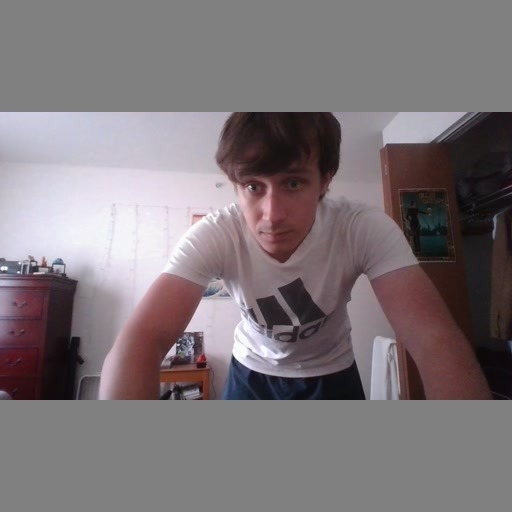

In [5]:
# 0a — letterbox. Skipped automatically if data/frames already has images (so a re-run is free).
if INTAKE_MODE == "skip":
    print("INTAKE_MODE = skip — using existing", MANIFEST)
elif H.list_frames(FRAMES_DIR):
    print(f"{len(H.list_frames(FRAMES_DIR))} letterboxed frames already in {FRAMES_DIR} — not redoing. "
          "Delete that folder to start over.")
elif INTAKE_MODE == "folder":
    H.letterbox_folder(RAW_IMAGES_DIR, FRAMES_DIR, size=IMAGE_SIZE)
elif INTAKE_MODE == "video":
    H.letterbox_video(VIDEO_PATH, FRAMES_DIR, sample_fps=VIDEO_SAMPLE_FPS, size=IMAGE_SIZE)
else:
    raise ValueError("INTAKE_MODE must be 'folder', 'video' or 'skip'")

# quick visual check that nothing was stretched
if INTAKE_MODE != "skip":
    from IPython.display import Image, display
    first = H.list_frames(FRAMES_DIR)[0]
    display(Image(f"{FRAMES_DIR}/{first}.jpg", width=256))

In [6]:
# 0b — import existing class labels (target / distractor / no_person) so you only have to draw boxes.
# labeled_frames.html has shirt colour + usable flag + close/mid per frame; TARGET_SHIRT decides which colour is the target.
if INTAKE_MODE == "skip":
    print("skipped")
else:
    sources_path = f"{FRAMES_DIR}/frame_sources.json"
    frame_sources = json.load(open(sources_path))   # frame_id -> original filename (written by 0a)
    labels = H.load_labels(LABELS_PATH)
    if LABELS_HTML and os.path.exists(LABELS_HTML):
        imported = H.import_labels_from_html(LABELS_HTML, frame_sources, TARGET_SHIRT)
        labels = H.merge_imported_labels(labels, imported)
    elif LABELS_CSV and os.path.exists(LABELS_CSV):
        imported = H.import_labels_from_csv(LABELS_CSV, frame_sources, TARGET_SHIRT)
        labels = H.merge_imported_labels(labels, imported)
    else:
        print("No label file given/found — you will set the class for every frame in the tagger.")
    H.save_labels(labels, LABELS_PATH)

Imported labels for 159 of 159 frames (159 cards in HTML)
93 person frames still need a box in the tagger


In [7]:
# 0c — tag boxes. Re-run this cell any time; it resumes at the first unconfirmed frame.
#   Box is x1,y1,x2,y2 in PIXELS of the 512x512 letterboxed image (the green rectangle shows what you typed).
#   'Save & next' -> saves labels.json and jumps to the next frame that still needs a box.
#   'Save with NO box' -> person frame where no box makes sense (e.g. only an elbow visible).
#   Imported empty/culled frames are already confirmed, so you only see person frames.
if INTAKE_MODE == "skip":
    print("skipped")
else:
    H.run_tagger(FRAMES_DIR, LABELS_PATH, auto_detect=AUTO_DETECT_BOXES, size=IMAGE_SIZE)

In [8]:
# 0d — write the manifest and print the class breakdown. Culled frames (usable=0) and frames with no class are left out.
if INTAKE_MODE == "skip":
    print("skipped")
else:
    labels = H.load_labels(LABELS_PATH)
    unconfirmed = [f for f in H.list_frames(FRAMES_DIR) if not labels.get(f, {}).get("_box_confirmed")]
    if unconfirmed:
        print(f"WARNING: {len(unconfirmed)} frames not confirmed in the tagger yet (first: {unconfirmed[0]}). "
              "They are still included if they have a class; IoU will just be n/a for them.")
    H.write_manifest(FRAMES_DIR, LABELS_PATH, MANIFEST, size=IMAGE_SIZE)

Wrote 149 records to /content/drive/MyDrive/Fargesia(AI car Buddy)/Eval/vlm_eval/data/manifest.json (skipped 0 unlabelled, 10 culled)
Frames: 149  ·  target: 29  ·  distractor: 65  ·  no person: 55  ·  with GT bbox: 0


In [9]:
# 0e — load the manifest (ALWAYS run this). This is the frame list every one of the four cells runs on.
manifest = H.load_manifest(MANIFEST)
H.print_manifest_summary(manifest)
n_d = sum(r["distractor_present"] for r in manifest)
assert n_d > 0, "No distractor frames — the false-positive metric would be undefined. Check TARGET_SHIRT / labels."

Frames: 149  ·  target: 29  ·  distractor: 65  ·  no person: 55  ·  with GT bbox: 0


## Step 5 — llama.cpp and the two model servers

Both models run under the same llama.cpp build, on the same CPU, so latency and memory are directly comparable.
`-hf repo:quant` downloads the model **and** its mmproj (vision projector) automatically into `MODEL_CACHE_DIR` on Drive.

In [10]:
# Build llama.cpp (CPU). ~3-5 min the first time; afterwards the binary is restored from Drive in seconds.
subprocess.run("apt-get install -y -qq libcurl4-openssl-dev > /dev/null", shell=True, check=True)  # needed for -hf downloads
SERVER_BIN = H.build_llama_cpp(LLAMA_DIR, cached_bin=LLAMA_BIN_CACHE)

Built /content/llama.cpp/build/bin/llama-server
Saved a copy to /content/drive/MyDrive/Fargesia(AI car Buddy)/Eval/vlm_eval/bin/llama-server


In [11]:
# Verify both repos exist and have a matching GGUF + an mmproj BEFORE downloading anything.
# Model B is allowed to be missing: the harness then runs A1/A2 only and says so, instead of dying mid-experiment.
ok_a, msg_a = H.verify_hf_repo(MODEL_A["hf_repo"], MODEL_A["quant"])
ok_b, msg_b = H.verify_hf_repo(MODEL_B["hf_repo"], MODEL_B["quant"])
print("Model A:", msg_a)
print("Model B:", msg_b)
assert ok_a, "Model A is the deployment candidate — cannot continue without it."
if not ok_b:
    print("\n*** Model B unavailable. Continuing with Model A only; B1/B2 will be skipped. ***")

Model A: LiquidAI/LFM2.5-VL-450M-GGUF: ok — LFM2.5-VL-450M-Q8_0.gguf + mmproj-LFM2.5-VL-450m-Q8_0.gguf  (mmproj file: mmproj-LFM2.5-VL-450m-Q8_0.gguf)
Model B: ggml-org/SmolVLM2-500M-Video-Instruct-GGUF: ok — SmolVLM2-500M-Video-Instruct-Q8_0.gguf + mmproj-SmolVLM2-500M-Video-Instruct-Q8_0.gguf  (mmproj file: mmproj-SmolVLM2-500M-Video-Instruct-Q8_0.gguf)


In [12]:
# Start both servers in the background and health-check them. The first start includes the download (~500 MB each).
servers = {}
servers["A"] = H.start_server(SERVER_BIN, MODEL_A["hf_repo"], MODEL_A["quant"], MODEL_A["port"],
                              MODEL_CACHE_DIR, f"{LOG_DIR}/server_A.log", SERVER_THREADS, MMPROJ_OVERRIDE["A"])
if ok_b:
    servers["B"] = H.start_server(SERVER_BIN, MODEL_B["hf_repo"], MODEL_B["quant"], MODEL_B["port"],
                                  MODEL_CACHE_DIR, f"{LOG_DIR}/server_B.log", SERVER_THREADS, MMPROJ_OVERRIDE["B"])

healthy = {}
healthy["A"] = H.wait_for_health(MODEL_A["port"], log_path=f"{LOG_DIR}/server_A.log")
healthy["B"] = ok_b and H.wait_for_health(MODEL_B["port"], log_path=f"{LOG_DIR}/server_B.log")
assert healthy["A"], "Model A server did not come up — see the log lines above."
if not healthy["B"]:
    print("*** Model B server not healthy — B1/B2 will be skipped. ***")

Started /content/llama.cpp/build/bin/llama-server -hf LiquidAI/LFM2.5-VL-450M-GGUF:Q8_0 --port 8081 --host 127.0.0.1  (pid 3637, log /content/drive/MyDrive/Fargesia(AI car Buddy)/Eval/vlm_eval/logs/server_A.log)
Started /content/llama.cpp/build/bin/llama-server -hf ggml-org/SmolVLM2-500M-Video-Instruct-GGUF:Q8_0 --port 8082 --host 127.0.0.1  (pid 3641, log /content/drive/MyDrive/Fargesia(AI car Buddy)/Eval/vlm_eval/logs/server_B.log)
port 8081: healthy after 30s
port 8082: healthy after 15s


## Step 6 — Prompts and grammar

Loaded from files, once, and the *same string objects* are used for both models — that is what makes the prompts
byte-identical across A and B. `{target}` is the only substitution.

In [13]:
def read(path):
    with open(path, encoding="utf-8") as f:
        return f.read()

PROMPT_V1 = read(f"{PROJECT_DIR}/prompts/prompt_v1.txt").replace("{target}", TARGET_DESCRIPTION)
PROMPT_V2 = read(f"{PROJECT_DIR}/prompts/prompt_v2.txt").replace("{target}", TARGET_DESCRIPTION)
GRAMMAR   = read(f"{PROJECT_DIR}/grammars/bbox.gbnf")
print("--- prompt v1 ---\n" + PROMPT_V1)
print("--- prompt v2 ---\n" + PROMPT_V2)

# Smoke test: one frame through each healthy server, free and grammar-constrained, so a
# bad build / missing mmproj / rejected `grammar` field shows up HERE, not 40 minutes in.
test_frame = next(r for r in manifest if r["target_present"])["path"]
for key, model in (("A", MODEL_A), ("B", MODEL_B)):
    if not healthy.get(key):
        continue
    for label, grammar in (("free", None), ("grammar", GRAMMAR)):
        raw, ms, timings, err = H.query_model(model["port"], PROMPT_V2, test_frame, grammar=grammar,
                                              max_tokens=MAX_TOKENS, seed=SEED)
        parsed, reason = H.parse_answer(raw)
        print(f"[{model['name']} / {label}] {ms:.0f} ms  err={err}\n   raw: {raw!r}\n   parsed: {parsed}  {reason}")
        if err and "grammar" in err.lower():
            print("   -> this llama-server build rejects the `grammar` field; update llama.cpp or use json_schema.")
        if err and ("image" in err.lower() or "mmproj" in err.lower() or "multimodal" in err.lower()):
            print(f"   -> server cannot take images: set MMPROJ_OVERRIDE['{key}'] to the mmproj filename printed by verify_hf_repo and restart.")

--- prompt v1 ---
Is there a person wearing a red shirt in this image? Reply with JSON containing match, confidence and bbox.

--- prompt v2 ---
You are the vision system of a robot that is searching for one specific person. Look at the image and decide whether the target is visible.

Target: person wearing a red shirt

Answer with a single JSON object and nothing else. No explanation, no markdown, no text before or after the JSON.

Schema (all three keys are required, in this order):
{"match": <true or false>, "confidence": <number from 0.0 to 1.0>, "bbox": <[x_min, y_min, x_max, y_max] or null>}

Rules:
- "match" is true only if a person matching the target description is visible. A person who does not match the description is NOT a match.
- "confidence" is how sure you are about the value of "match".
- "bbox" is the box around the matching person. Coordinates are fractions of the image width and height, from 0.0 (left/top) to 1.0 (right/bottom). x_min < x_max and y_min < y_max.
- If

## Step 7 — Run the four cells

Plain list, four entries. Each cell appends one JSON line per frame to `results/raw/<cell>.jsonl` as it goes;
re-running skips frames already answered. Temperature 0 and a fixed seed everywhere.

In [14]:
# The 2x2. Same PROMPT_V1 / PROMPT_V2 / GRAMMAR objects in both rows -> byte-identical by construction.
CELLS = [
    {"cell": "A1", "model": MODEL_A, "key": "A", "prompt_name": "v1", "prompt": PROMPT_V1, "grammar": None},
    {"cell": "A2", "model": MODEL_A, "key": "A", "prompt_name": "v2", "prompt": PROMPT_V2, "grammar": GRAMMAR},
    {"cell": "B1", "model": MODEL_B, "key": "B", "prompt_name": "v1", "prompt": PROMPT_V1, "grammar": None},
    {"cell": "B2", "model": MODEL_B, "key": "B", "prompt_name": "v2", "prompt": PROMPT_V2, "grammar": GRAMMAR},
]
assert CELLS[0]["prompt"] == CELLS[2]["prompt"] and CELLS[1]["prompt"] == CELLS[3]["prompt"]
assert CELLS[1]["grammar"] == CELLS[3]["grammar"]

# provenance for the write-up
import hashlib, time
json.dump({"date": time.strftime("%Y-%m-%d %H:%M"), "target_description": TARGET_DESCRIPTION,
           "target_shirt": TARGET_SHIRT, "n_frames": len(manifest), "seed": SEED, "max_tokens": MAX_TOKENS,
           "malformed_policy": MALFORMED_POLICY, "model_a": MODEL_A, "model_b": MODEL_B,
           "prompt_v1_sha1": hashlib.sha1(PROMPT_V1.encode()).hexdigest(),
           "prompt_v2_sha1": hashlib.sha1(PROMPT_V2.encode()).hexdigest(),
           "grammar_sha1": hashlib.sha1(GRAMMAR.encode()).hexdigest()},
          open(f"{RESULTS_DIR}/run_info.json", "w"), indent=1)

for c in CELLS:
    if not healthy.get(c["key"]):
        print(f"[{c['cell']}] skipped — {c['model']['name']} server not available")
        continue
    pid = servers[c["key"]].pid
    H.run_cell(c["cell"], c["model"]["port"], pid, c["prompt"], c["grammar"], manifest, RAW_DIR,
               max_tokens=MAX_TOKENS, seed=SEED)

[A1] 0 frames already done, 149 to go
[A1] 10/149  last 1839 ms  elapsed 0.3 min  eta 4.8 min
[A1] 20/149  last 1812 ms  elapsed 0.7 min  eta 4.3 min
[A1] 30/149  last 1837 ms  elapsed 1.0 min  eta 4.0 min
[A1] 40/149  last 1839 ms  elapsed 1.3 min  eta 3.6 min
[A1] 50/149  last 1856 ms  elapsed 1.7 min  eta 3.3 min
[A1] 60/149  last 1831 ms  elapsed 2.0 min  eta 3.0 min
[A1] 70/149  last 1868 ms  elapsed 2.3 min  eta 2.6 min
[A1] 80/149  last 1835 ms  elapsed 2.7 min  eta 2.3 min
[A1] 90/149  last 1881 ms  elapsed 3.0 min  eta 2.0 min
[A1] 100/149  last 1838 ms  elapsed 3.3 min  eta 1.6 min
[A1] 110/149  last 1859 ms  elapsed 3.7 min  eta 1.3 min
[A1] 120/149  last 1817 ms  elapsed 4.0 min  eta 1.0 min
[A1] 130/149  last 1831 ms  elapsed 4.3 min  eta 0.6 min
[A1] 140/149  last 1866 ms  elapsed 4.7 min  eta 0.3 min
[A1] 149/149  last 2731 ms  elapsed 5.0 min  eta 0.0 min
[A1] done. peak server RSS: 7320.09765625 MB
[A2] 0 frames already done, 149 to go
[A2] 10/149  last 2042 ms  elapse

## Step 8 — Metrics (4 cells × 6 metrics)

The malformed-answer policy is printed at the top of the table so the accuracy numbers are never ambiguous.

In [15]:
CELL_INFO = {c["cell"]: {"model": c["model"]["name"], "prompt": c["prompt_name"], "grammar": c["grammar"] is not None}
             for c in CELLS}
metrics_list = [H.compute_metrics(c["cell"], RAW_DIR, manifest, MALFORMED_POLICY) for c in CELLS]
metrics = {m["cell"]: m for m in metrics_list}

from IPython.display import Markdown, display
table_md = H.write_metrics_table(metrics_list, CELL_INFO, RESULTS_DIR, MALFORMED_POLICY)
display(Markdown(table_md))
print("written:", f"{RESULTS_DIR}/metrics.md", f"{RESULTS_DIR}/metrics.csv")

# 2x2 results

Malformed answers in free-generation cells are scored with policy **`count_as_miss`** (a malformed answer counts as a wrong answer; on a distractor frame it counts as a false positive).

| Cell | Model | Prompt | Match acc. | False-pos. rate | Mean IoU (n) | Malformed rate | Latency mean / p95 ms | Peak RSS MB |
|---|---|---|---|---|---|---|---|---|
| A1 | LFM2.5-VL-450M | v1 | 0.0% | 100.0% (n=65) | n/a (0) | 100.0% (149) | 1996 / 2652 | 7320 |
| A2 | LFM2.5-VL-450M | v2 + grammar | 77.9% | 24.6% (n=65) | n/a (0) | 0.0% (0) | 2272 / 3040 | 7330 |
| B1 | SmolVLM2-500M | v1 | 0.0% | 100.0% (n=65) | n/a (0) | 100.0% (149) | 3426 / 4584 | 3582 |
| B2 | SmolVLM2-500M | v2 + grammar | 19.5% | 100.0% (n=65) | n/a (0) | 0.0% (0) | 2954 / 3752 | 3591 |


written: /content/drive/MyDrive/Fargesia(AI car Buddy)/Eval/vlm_eval/results/metrics.md /content/drive/MyDrive/Fargesia(AI car Buddy)/Eval/vlm_eval/results/metrics.csv


## Step 9 — Error analysis and findings

Worst false positives (highest confidence first), false alarms on empty frames, missed targets, worst IoU,
every malformed output with its raw text — each with the frame path — then the A1→A2 / B1→B2 deltas,
the interaction, and **the verdict on which model to deploy**.

In [16]:
report_md = H.write_error_analysis([c["cell"] for c in CELLS], RAW_DIR, manifest, RESULTS_DIR, metrics, CELL_INFO)
display(Markdown(report_md[report_md.index("# Findings"):]))     # findings + verdict inline; full report in the file
print("full report:", f"{RESULTS_DIR}/error_analysis.md")

# Findings

**LFM2.5-VL-450M — v1 → v2 + grammar:** FPR 100.0% → 24.6% (-75.4 pp); accuracy 0.0% → 77.9% (+77.9 pp); malformed 100.0% → 0.0%; IoU n/a → n/a.

**SmolVLM2-500M — v1 → v2 + grammar:** FPR 100.0% → 100.0% (+0.0 pp); accuracy 0.0% → 19.5% (+19.5 pp); malformed 100.0% → 0.0%; IoU n/a → n/a.

## Interaction (model x prompt)

Refinement changed FPR by -75.4 pp for LFM2.5-VL-450M and +0.0 pp for SmolVLM2-500M; accuracy by +77.9 pp and +19.5 pp.

**Interaction present:** refinement helped the stronger baseline more (+77.9 pp vs +19.5 pp for SmolVLM2-500M), widening the gap.

## Which model to deploy

**Deploy LFM2.5-VL-450M** (with the v2 prompt + grammar). Reason: lower false-positive rate (24.6% vs 100.0%). Latency 2272 ms (LFM2.5-VL-450M) vs 2954 ms (SmolVLM2-500M); peak RSS 7330 vs 3591 MB. Runner-up: SmolVLM2-500M.

Rule used: FPR first (a wrong-person follow is the failure that matters), then accuracy, then IoU, then latency; differences under 2 pp / 0.02 are treated as ties. Latency here is Colab CPU, not the Pi 5 — only the ratio between models is meaningful.


full report: /content/drive/MyDrive/Fargesia(AI car Buddy)/Eval/vlm_eval/results/error_analysis.md


In [17]:
# Stop the servers when you are done (frees ~1.5 GB RAM). Leave them running if you want to re-run a cell.
for key, proc in servers.items():
    proc.terminate()
    print("stopped server", key)

stopped server A
stopped server B
